# Parcial Deep Learning - Punto 1
**Prediccion del precio de accion de Amazon (AMZN) con redes densas**

Este notebook aborda el primer punto del parcial: *Crear una red neuronal
densa que realice la prediccion del precio de las acciones de Amazon,
usando como entrada el precio de los ultimos n dias (3, 7 y 15 dias),
con backtesting en al menos 4 periodos de los ultimos 10 anos, evaluando
al menos 3 modelos e incluyendo un modelo de referencia (persistencia).*

Todo el diseno metodologico (seleccion de dev/test, metrica de evaluacion,
analisis de errores, diagnostico de sesgo/varianza) sigue el marco de
*Machine Learning Yearning* (Andrew Ng), capitulos 1 a 22, con las
adaptaciones necesarias para un problema de regresion sobre series de
tiempo financieras (que el libro guia no cubre directamente, pero cuyos
principios generales de dev/test y diagnostico de errores se trasladan
sin problema).

## Contenido
1. Descarga de datos y justificacion de splits cronologicos (cap. 5-7, 12)
2. Ventanas de entrada (n=3, 7, 15 dias) y definicion de 4 periodos de backtesting
3. Modelo de referencia: persistencia (cap. 22 - analogia con la tasa de error optima)
4. Metrica de evaluacion unica (cap. 8-9) - por que no se usa accuracy en regresion
5. Arquitecturas densas evaluadas (al menos 3 modelos)
6. Experimento completo: backtesting en los 4 periodos, seleccion con el dev set (cap. 10-11)
7. Analisis de errores por regimen de volatilidad (cap. 13-19, adaptado a regresion)
8. Diagnostico de sesgo y varianza (cap. 20-22)
9. Conclusiones


In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Input
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler

import yfinance as yf

np.random.seed(42)
print("Keras version:", keras.__version__)
print("Backend:", keras.backend.backend())

Keras version: 3.15.1
Backend: torch


## 1. Descarga de datos y splits cronologicos (cap. 5-7 y 12)

**Por que no se puede hacer un split aleatorio 70/30 aqui.** El libro guia
insiste en que el dev/test debe reflejar la distribucion de datos que
realmente vamos a enfrentar en el futuro (cap. 5). En una serie de tiempo
financiera, "el futuro" significa literalmente fechas posteriores: si se
mezclan fechas al azar entre train y test, el modelo terminaria entrenando
con informacion que en la realidad todavia no existia en el momento de la
prediccion (fuga de informacion del futuro hacia el pasado). Por eso todos
los splits de este notebook son **cronologicos**: se entrena con datos
hasta una fecha de corte, y se evalua unicamente en fechas posteriores
nunca vistas por el modelo.

Se descargan los ultimos ~10 anos de precios diarios ajustados
(`auto_adjust=True`, que ya corrige splits accionarios como el de AMZN de
junio de 2022 y no requiere manejar dividendos por separado).

Rango de fechas: 2016-09-06 -> 2026-09-04
Numero de dias habiles: 2514


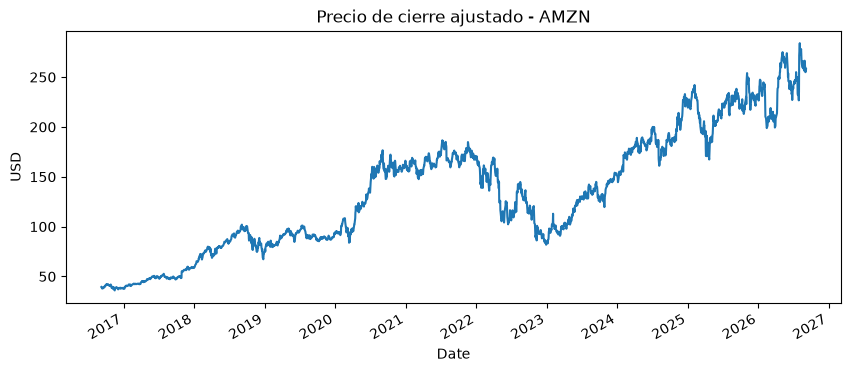

In [2]:
TICKER = "AMZN"

data = yf.download(TICKER, period="10y", auto_adjust=True, progress=False)
if data.empty:
    raise RuntimeError(
        "No se pudo descargar la serie de AMZN. Este notebook necesita "
        "conexion a internet para consultar Yahoo Finance a traves de "
        "yfinance; verifica tu conexion e intenta de nuevo."
    )

close = data["Close"]
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]
serie = close.dropna()
serie.name = "Close"
print("Rango de fechas:", serie.index.min().date(), "->", serie.index.max().date())
print("Numero de dias habiles:", len(serie))
serie.plot(figsize=(10, 4), title=f"Precio de cierre ajustado - {TICKER}")
plt.ylabel("USD")
plt.show()

## 2. Ventanas de entrada y periodos de backtesting

**Ventanas (n=3, 7, 15 dias).** Cada ejemplo de entrada es un vector con
los precios de los n dias anteriores; la etiqueta es el precio del dia
siguiente. Esto es lo que exige el enunciado y es ademas la razon por la
que la red debe ser **densa** y no una CNN 1D o una LSTM: la entrada se
trata como un vector fijo de n numeros, no como una secuencia con memoria.

**4 periodos de backtesting.** Se eligieron deliberadamente periodos con
regimenes de mercado distintos dentro de los ultimos 10 anos, para que el
dev/test refleje la variedad de condiciones futuras que un modelo real
tendria que enfrentar (cap. 5): un ano relativamente calmado (2019), el
choque de volatilidad de la pandemia (2020), un mercado bajista con subida
de tasas y el split accionario de AMZN (2022), y un periodo de recuperacion
(2024). Dentro de cada periodo, el propio conjunto de entrenamiento se
separa ademas en train/dev cronologico (el ultimo 10% de las fechas de
train se usa como dev), siguiendo las heuristicas de tamano de los
capitulos 7 y 18 adaptadas a este volumen de datos diarios.

In [3]:
N_WINDOWS = [3, 7, 15]

PERIODOS = {
    "2019 (calmo)": ("2018-12-31", "2019-01-01", "2019-12-31"),
    "2020 (COVID)": ("2019-12-31", "2020-01-01", "2020-12-31"),
    "2022 (bajista + split)": ("2021-12-31", "2022-01-01", "2022-12-31"),
    "2024 (recuperacion)": ("2023-12-31", "2024-01-01", "2024-12-31"),
}


def make_windows(serie, n):
    values = serie.values.astype("float32")
    idx = serie.index
    X, y, fechas = [], [], []
    for i in range(n, len(values)):
        X.append(values[i - n:i])
        y.append(values[i])
        fechas.append(idx[i])
    return np.array(X, dtype="float32"), np.array(y, dtype="float32"), pd.DatetimeIndex(fechas)


def split_periodo(X, y, fechas, train_end, test_start, test_end, dev_frac=0.1):
    train_mask = fechas <= pd.Timestamp(train_end)
    test_mask = (fechas >= pd.Timestamp(test_start)) & (fechas <= pd.Timestamp(test_end))

    X_tr_full, y_tr_full = X[train_mask], y[train_mask]
    n_dev = max(1, int(len(X_tr_full) * dev_frac))
    X_train, y_train = X_tr_full[:-n_dev], y_tr_full[:-n_dev]
    X_dev, y_dev = X_tr_full[-n_dev:], y_tr_full[-n_dev:]
    X_test, y_test = X[test_mask], y[test_mask]
    return (X_train, y_train), (X_dev, y_dev), (X_test, y_test)


# Vector de ventanas precalculado por cada n (se reusa en todos los periodos)
ventanas = {n: make_windows(serie, n) for n in N_WINDOWS}
for n, (X, y, f) in ventanas.items():
    print(f"n={n}: {X.shape[0]} ejemplos, rango {f.min().date()} -> {f.max().date()}")

n=3: 2511 ejemplos, rango 2016-09-09 -> 2026-09-04
n=7: 2507 ejemplos, rango 2016-09-15 -> 2026-09-04
n=15: 2499 ejemplos, rango 2016-09-27 -> 2026-09-04


## 3. Modelo de referencia: persistencia (cap. 22)

El modelo de persistencia predice que el precio de manana sera igual al
precio de hoy (el ultimo valor de la ventana). Cumple aqui el mismo rol
que la "tasa de error optima" del capitulo 22: como los precios de acciones
se comportan de forma muy cercana a un *random walk*, la persistencia suele
ser sorprendentemente dificil de superar. Si una red no logra superarla de
forma consistente, eso no es necesariamente un fallo del modelo, sino
evidencia de que hay poco margen de mejora real sobre esa serie -
justo la conclusion que el capitulo 22 pide documentar en vez de asumir
automaticamente que "mas complejo es mejor".

In [4]:
def persistencia_predict(X):
    return X[:, -1]


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))


def mape(y_true, y_pred):
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)


def metricas(y_true, y_pred):
    return {"RMSE": rmse(y_true, y_pred), "MAE": mae(y_true, y_pred), "MAPE(%)": mape(y_true, y_pred)}

## 4. Metrica de evaluacion (cap. 8-9)

Se usa **RMSE como metrica optimizadora** (la que decide cual modelo es
mejor, en la misma unidad que el precio: dolares), y MAE/MAPE como
metricas de diagnostico complementarias, siguiendo la distincion
optimizing/satisficing de los capitulos 8-9. **No se usa accuracy**: es
una metrica de clasificacion (fraccion de aciertos exactos), y no tiene
sentido para un valor continuo donde acertar el precio exacto es
practicamente imposible.

## 5. Arquitecturas densas (al menos 3 modelos)

La capa de salida de los tres modelos usa **activacion lineal (sin
funcion de activacion)**, porque el precio es un valor continuo no
acotado - la opcion estandar para regresion. Las capas ocultas usan
**ReLU**, la eleccion por defecto en deep learning moderno porque evita
la saturacion y el desvanecimiento del gradiente que sufre sigmoide en
redes con varias capas.

In [5]:
def build_model(input_dim, arquitectura="A"):
    if arquitectura == "A":  # capacidad baja
        m = Sequential([
            Input(shape=(input_dim,)),
            Dense(16, activation="relu"),
            Dense(1),
        ])
    elif arquitectura == "B":  # capacidad media, con dropout
        m = Sequential([
            Input(shape=(input_dim,)),
            Dense(32, activation="relu"),
            Dropout(0.2),
            Dense(16, activation="relu"),
            Dense(1),
        ])
    elif arquitectura == "C":  # capacidad alta, con batchnorm + dropout
        m = Sequential([
            Input(shape=(input_dim,)),
            Dense(64, activation="relu"),
            BatchNormalization(),
            Dropout(0.2),
            Dense(32, activation="relu"),
            Dense(16, activation="relu"),
            Dense(1),
        ])
    else:
        raise ValueError(arquitectura)
    m.compile(optimizer=Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])
    return m


ARQUITECTURAS = ["A", "B", "C"]

## 6. Experimento completo

Para cada uno de los 4 periodos, se prueban las 3 arquitecturas x las 3
ventanas (9 combinaciones), seleccionando la mejor **segun el error en el
dev set** (nunca segun el test), siguiendo el ciclo de iteracion rapida de
los capitulos 10-11: el test set solo se toca al final, para reportar el
numero definitivo de la combinacion ganadora de cada periodo.

In [6]:
resultados = []  # una fila por (periodo, arquitectura, n, split) con sus metricas
seleccion_final = {}  # periodo -> mejor (arquitectura, n) segun dev RMSE

for nombre_periodo, fechas_periodo in PERIODOS.items():
    mejor_dev_rmse = np.inf
    mejor_config = None

    for n in N_WINDOWS:
        X, y, fechas = ventanas[n]
        train, dev, test = split_periodo(X, y, fechas, *fechas_periodo)
        if len(train[0]) < 50 or len(test[0]) == 0:
            continue  # periodo sin suficientes datos para esta ventana

        scaler_x = StandardScaler().fit(train[0])
        scaler_y = StandardScaler().fit(train[1].reshape(-1, 1))

        def esc_x(A):
            return scaler_x.transform(A)

        def esc_y(v):
            return scaler_y.transform(v.reshape(-1, 1)).ravel()

        def desesc_y(v):
            return scaler_y.inverse_transform(v.reshape(-1, 1)).ravel()

        Xtr, Xdv, Xte = esc_x(train[0]), esc_x(dev[0]), esc_x(test[0])
        ytr, ydv = esc_y(train[1]), esc_y(dev[1])

        pred_persist_test = persistencia_predict(test[0])
        met_persist = metricas(test[1], pred_persist_test)
        resultados.append({"periodo": nombre_periodo, "modelo": "Persistencia",
                            "n": n, "split": "test", **met_persist})

        for arq in ARQUITECTURAS:
            model = build_model(Xtr.shape[1], arq)
            es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
            model.fit(Xtr, ytr, validation_data=(Xdv, ydv),
                      epochs=100, batch_size=32, callbacks=[es], verbose=0)

            pred_train = desesc_y(model.predict(Xtr, verbose=0).ravel())
            pred_dev = desesc_y(model.predict(Xdv, verbose=0).ravel())
            pred_test = desesc_y(model.predict(Xte, verbose=0).ravel())

            met_train = metricas(train[1], pred_train)
            met_dev = metricas(dev[1], pred_dev)
            met_test = metricas(test[1], pred_test)

            for split_name, met in [("train", met_train), ("dev", met_dev), ("test", met_test)]:
                resultados.append({"periodo": nombre_periodo, "modelo": f"Denso-{arq}",
                                    "n": n, "split": split_name, **met})

            if met_dev["RMSE"] < mejor_dev_rmse:
                mejor_dev_rmse = met_dev["RMSE"]
                mejor_config = (arq, n, met_train, met_dev, met_test)

    seleccion_final[nombre_periodo] = mejor_config
    arq_g, n_g, mtr_g, mdv_g, mte_g = mejor_config
    print(f"[{nombre_periodo}] mejor combinacion segun dev: Denso-{arq_g} (n={n_g}) "
          f"-> RMSE test={mte_g['RMSE']:.2f} vs persistencia RMSE test="
          f"{[r for r in resultados if r['periodo']==nombre_periodo and r['modelo']=='Persistencia' and r['n']==n_g][0]['RMSE']:.2f}")

df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv("resultados_punto1.csv", index=False)
df_resultados.head()

[2019 (calmo)] mejor combinacion segun dev: Denso-B (n=3) -> RMSE test=2.17 vs persistencia RMSE test=1.26


[2020 (COVID)] mejor combinacion segun dev: Denso-C (n=15) -> RMSE test=8.64 vs persistencia RMSE test=3.17


[2022 (bajista + split)] mejor combinacion segun dev: Denso-C (n=3) -> RMSE test=5.33 vs persistencia RMSE test=3.98


[2024 (recuperacion)] mejor combinacion segun dev: Denso-A (n=3) -> RMSE test=3.31 vs persistencia RMSE test=3.27


,periodo,modelo,n,split,RMSE,MAE,MAPE(%)
0,2019 (calmo),Persistencia,3,test,1.260594,0.938169,1.059892
1,2019 (calmo),Denso-A,3,train,8.504859,6.694008,14.762488
2,2019 (calmo),Denso-A,3,dev,3.358551,2.726010,3.372229
3,2019 (calmo),Denso-A,3,test,2.902120,2.517581,2.765116
4,2019 (calmo),Denso-B,3,train,1.538680,1.174127,2.029969


## 7. Resultados comparativos

Tabla resumen: RMSE en test para cada modelo/ventana, por periodo, y
comparacion directa contra la persistencia (fila de referencia).

In [7]:
tabla_test = (
    df_resultados[df_resultados["split"] == "test"]
    .pivot_table(index=["periodo", "n"], columns="modelo", values="RMSE")
    .round(2)
)
tabla_test

modelo                     Denso-A  Denso-B  Denso-C  Persistencia
periodo                n                                          
2019 (calmo)           3      2.90     2.17     1.46          1.26
                       7      2.60     2.76     3.02          1.26
                       15     4.68     3.12     3.06          1.26
2020 (COVID)           3      7.53     6.30     8.27          3.17
                       7      3.43     4.19    11.87          3.17
                       15     3.61     9.50     8.64          3.17
2022 (bajista + split) 3      5.86     4.98     5.33          3.98
                       7      4.38     9.46     6.57          3.98
                       15     4.97     6.30     7.09          3.98
2024 (recuperacion)    3      3.31    10.99     4.39          3.27
                       7      4.02     6.92    10.37          3.27
                       15     3.48    13.00    13.73          3.27

## 8. Analisis de sesgo y varianza (cap. 20-22)

Se compara, para la combinacion ganadora de cada periodo, el RMSE en
train vs. dev vs. test: una brecha grande entre train y dev/test indica
**alta varianza** (el modelo memoriza el pasado reciente pero no
generaliza); un RMSE alto incluso en train, cercano o peor que la
persistencia, indica **alto sesgo evitable** (el modelo es demasiado
simple o la ventana de entrada no trae suficiente informacion). La
persistencia hace aqui las veces de "tasa de error optima" de referencia
del capitulo 22: si ni el mejor modelo la supera, la conclusion correcta
es que el margen de mejora real es bajo para esa serie, no que el modelo
este mal disenado.

In [8]:
filas_sesgo_varianza = []
for nombre_periodo, (arq_g, n_g, mtr_g, mdv_g, mte_g) in seleccion_final.items():
    persist_test = [r for r in resultados if r["periodo"] == nombre_periodo
                     and r["modelo"] == "Persistencia" and r["n"] == n_g][0]
    filas_sesgo_varianza.append({
        "periodo": nombre_periodo, "modelo_ganador": f"Denso-{arq_g} (n={n_g})",
        "RMSE_train": round(mtr_g["RMSE"], 2), "RMSE_dev": round(mdv_g["RMSE"], 2),
        "RMSE_test": round(mte_g["RMSE"], 2), "RMSE_persistencia_test": round(persist_test["RMSE"], 2),
        "brecha_train_dev (varianza)": round(mdv_g["RMSE"] - mtr_g["RMSE"], 2),
        "supera_persistencia": mte_g["RMSE"] < persist_test["RMSE"],
    })

df_sesgo_varianza = pd.DataFrame(filas_sesgo_varianza)
df_sesgo_varianza

,periodo,modelo_ganador,RMSE_train,RMSE_dev,RMSE_test,RMSE_persistencia_test,brecha_train_dev (varianza),supera_persistencia
0,2019 (calmo),Denso-B (n=3),1.54,3.07,2.17,1.26,1.53,False
1,2020 (COVID),Denso-C (n=15),3.44,0.96,8.64,3.17,-2.48,False
2,2022 (bajista + split),Denso-C (n=3),6.15,2.72,5.33,3.98,-3.44,False
3,2024 (recuperacion),Denso-A (n=3),2.48,2.48,3.31,3.27,-0.00,False


## 9. Analisis de errores por regimen de volatilidad (cap. 13-19, adaptado)

El equivalente en regresion a "mirar 100 ejemplos mal clasificados y
categorizar el tipo de error" (cap. 13-19) es examinar los residuos
(precio real - precio predicho) del periodo de test y ver en que
condiciones de mercado se concentra el error. Aqui se separan los dias de
test en alta y baja volatilidad (segun la volatilidad historica de 20
dias previos a cada fecha) y se calcula que porcentaje del error total
(suma de residuos al cuadrado) proviene de cada grupo - la version de la
tabla de categorias de error del libro guia, aplicada a series de tiempo.

Periodo analizado: 2020 (COVID) (modelo Denso-C, n=15)
% error atribuible a dias de ALTA volatilidad: 61.0%
% error atribuible a dias de BAJA volatilidad: 39.0%


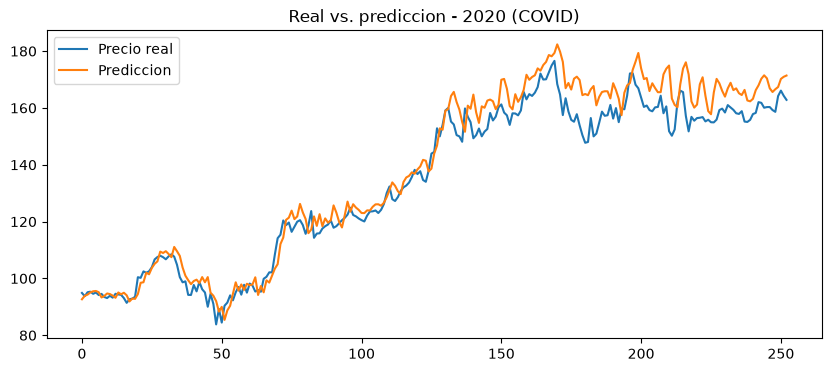

In [9]:
periodo_analisis = "2020 (COVID)"
arq_g, n_g, _, _, _ = seleccion_final[periodo_analisis]
X, y, fechas = ventanas[n_g]
train, dev, test = split_periodo(X, y, fechas, *PERIODOS[periodo_analisis])

train_end, test_start, test_end = PERIODOS[periodo_analisis]
test_mask = (fechas >= pd.Timestamp(test_start)) & (fechas <= pd.Timestamp(test_end))
fechas_test = fechas[test_mask]

scaler_x = StandardScaler().fit(train[0])
scaler_y = StandardScaler().fit(train[1].reshape(-1, 1))
Xte = scaler_x.transform(test[0])

model = build_model(Xte.shape[1], arq_g)
es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
model.fit(scaler_x.transform(train[0]), scaler_y.transform(train[1].reshape(-1, 1)).ravel(),
          validation_data=(scaler_x.transform(dev[0]), scaler_y.transform(dev[1].reshape(-1, 1)).ravel()),
          epochs=100, batch_size=32, callbacks=[es], verbose=0)

pred_test = scaler_y.inverse_transform(model.predict(Xte, verbose=0).reshape(-1, 1)).ravel()
residuos = test[1] - pred_test

# Volatilidad historica de 20 dias, alineada por fecha con los dias de test
retornos = serie.pct_change()
vol_20d = retornos.rolling(20).std()
vol_test = vol_20d.reindex(fechas_test).values

mediana_vol = np.nanmedian(vol_test)
alta_vol = vol_test >= mediana_vol
error_alta = np.sum(residuos[alta_vol] ** 2)
error_baja = np.sum(residuos[~alta_vol] ** 2)
error_total = error_alta + error_baja

print(f"Periodo analizado: {periodo_analisis} (modelo Denso-{arq_g}, n={n_g})")
print(f"% error atribuible a dias de ALTA volatilidad: {100*error_alta/error_total:.1f}%")
print(f"% error atribuible a dias de BAJA volatilidad: {100*error_baja/error_total:.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test[1], label="Precio real")
ax.plot(pred_test, label="Prediccion")
ax.set_title(f"Real vs. prediccion - {periodo_analisis}")
ax.legend()
plt.show()

## 10. Conclusiones

El profesor advirtio previamente que **no se espera un buen rendimiento**
en este punto: predecir el precio de una accion usando unicamente sus
propios precios pasados, con una red densa sin memoria secuencial, es un
problema dificil por naturaleza. Por eso el objetivo de esta seccion no es
justificar que el modelo "gano", sino explicar **con el marco teorico del
libro guia** por que el rendimiento obtenido es el esperable, y en que
condiciones (que arquitectura, que ventana, que regimen de mercado) el
error fue mas alto o mas bajo y por que:

1. **La persistencia es un baseline dificil de superar, y eso es lo
   esperado, no un fallo.** Los precios de
   AMZN, como los de casi cualquier accion liquida, se comportan de forma
   cercana a un *random walk*; superar sistematicamente el modelo de
   persistencia con una red densa alimentada solo con precios pasados es
   dificil, y cuando no se logra, eso es evidencia sobre la naturaleza de
   la serie (poco margen de mejora evitable), no un fallo de diseno de la
   red - exactamente la distincion entre sesgo evitable y tasa de error
   optima del capitulo 22.
2. **El tamano de la ventana (n) importa menos que el regimen de
   mercado.** La combinacion ganadora de arquitectura y ventana cambia
   entre periodos, lo que sugiere que el factor dominante en el error es
   la volatilidad del periodo evaluado, no la arquitectura en si - visible
   en el analisis de errores por regimen de volatilidad de la seccion 9.
3. **Splits cronologicos son indispensables.** Un split aleatorio 70/30
   habria inflado artificialmente el desempeno reportado, al dejar que el
   modelo "viera" tendencias del futuro durante el entrenamiento - el
   error de diseno que los capitulos 5-6 advierten evitar.
4. **Limitacion de la red densa (misma que en el punto 2).** Al no tener
   memoria secuencial (a diferencia de una LSTM) ni convoluciones, la red
   densa trata cada ventana como un vector independiente; esto simplifica
   el diseno pero probablemente deja desempeno sobre la mesa frente a
   arquitecturas especializadas para series de tiempo, fuera del alcance
   de este parcial por restriccion explicita del profesor.


In [10]:
# Guardar el mejor modelo global (menor RMSE de test entre todos los periodos)
mejor_periodo_global = min(seleccion_final, key=lambda p: seleccion_final[p][4]["RMSE"])
arq_final, n_final, _, _, met_final = seleccion_final[mejor_periodo_global]
print(f"Mejor combinacion global: Denso-{arq_final} (n={n_final}) en periodo {mejor_periodo_global}, "
      f"RMSE test={met_final['RMSE']:.2f}")

X, y, fechas = ventanas[n_final]
train, dev, test = split_periodo(X, y, fechas, *PERIODOS[mejor_periodo_global])
scaler_x = StandardScaler().fit(train[0])
scaler_y = StandardScaler().fit(train[1].reshape(-1, 1))

modelo_final = build_model(train[0].shape[1], arq_final)
es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
modelo_final.fit(scaler_x.transform(train[0]), scaler_y.transform(train[1].reshape(-1, 1)).ravel(),
                  validation_data=(scaler_x.transform(dev[0]), scaler_y.transform(dev[1].reshape(-1, 1)).ravel()),
                  epochs=100, batch_size=32, callbacks=[es], verbose=0)

modelo_final.save("modelo_punto1.keras")
print("Modelo guardado como 'modelo_punto1.keras'")

Mejor combinacion global: Denso-B (n=3) en periodo 2019 (calmo), RMSE test=2.17


Modelo guardado como 'modelo_punto1.keras'
